In [7]:
!pip install tensorflow

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
df = pd.read_csv('energy_dataset_cleaned.csv')

In [10]:
# convert month names to numbers
df['month'] = pd.to_datetime(df['month'], format='%B').dt.month

# convert day of week to numbers
df['day_of_week'] = pd.to_datetime(df['day_of_week'], format='%A').dt.dayofweek

In [11]:
#preparing data for modeling
df_dl = df.drop(columns=['datetime','day_name'])

X = df_dl.drop(columns=['energy_consumption(MW)'])
y = df_dl['energy_consumption(MW)']

In [12]:
# Train-test split (80-20) for time series data (no shuffling)
split = int(len(df_dl)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [13]:
# Scaling features and target variable
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [14]:
# Reshaping data for LSTM input (samples, timesteps, features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [15]:
# Building the LSTM model

lstm_model = Sequential()

lstm_model.add(LSTM(64, return_sequences=False, input_shape=(1, X_train.shape[1])))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = lstm_model.fit(
    X_train_lstm,
    y_train_scaled,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0187 - val_loss: 0.0166
Epoch 2/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0187 - val_loss: 0.0162
Epoch 3/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0187 - val_loss: 0.0159
Epoch 4/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0187 - val_loss: 0.0163
Epoch 5/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0187 - val_loss: 0.0162
Epoch 6/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0187 - val_loss: 0.0162
Epoch 7/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 0.0187 - val_loss: 0.0164
Epoch 8/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0187 - val_loss: 0.0167
Epoch 9/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0187 - val_loss: 0.0162
Epoch 10/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0187 - val_loss: 0.0165
Epoch 11/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0187 - val_loss: 0.0162
Epoch 12/20
1636/1636 ━━

In [20]:
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)

y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)

909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [21]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae = mean_absolute_error(y_test, y_pred_lstm)
r2 = r2_score(y_test, y_pred_lstm)

print("=== LSTM Results ===")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

=== LSTM Results ===
RMSE: 6570.45
MAE: 5294.36
R² Score: -0.0129


In [22]:
data = df[['energy_consumption(MW)']].copy()
values = data.values

In [23]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(values)

In [24]:
def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

window_size = 24

X, y = create_sequences(scaled_data, window_size)

In [25]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [26]:
model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(window_size, 1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 148s 90ms/step - loss: 2.2277e-04 - val_loss: 6.6706e-04
Epoch 2/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 198s 88ms/step - loss: 2.2266e-04 - val_loss: 0.0010
Epoch 3/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 144s 88ms/step - loss: 2.1871e-04 - val_loss: 7.8170e-04
Epoch 4/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 145s 89ms/step - loss: 2.1089e-04 - val_loss: 6.6131e-04
Epoch 5/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 147s 90ms/step - loss: 2.0909e-04 - val_loss: 5.9211e-04
Epoch 6/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 201s 89ms/step - loss: 2.0540e-04 - val_loss: 5.2613e-04
Epoch 7/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 149s 91ms/step - loss: 2.0394e-04 - val_loss: 6.3740e-04
Epoch 8/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 149s 91ms/step - loss: 1.9961e-04 - val_loss: 8.0617e-04
Epoch 9/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 206s 93ms/step - loss: 2.0118e-04 - val_loss: 6.7050e-04
Epoch 10/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 159s 97ms/step - loss: 1.9726e-04 - val_loss: 8.3548e-04
Epoch 11/20
1

In [31]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

909/909 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step


In [34]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("=== LSTM Results ===")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

=== LSTM Results ===
RMSE: 1211.13
MAE: 919.16
R² Score: 0.9656


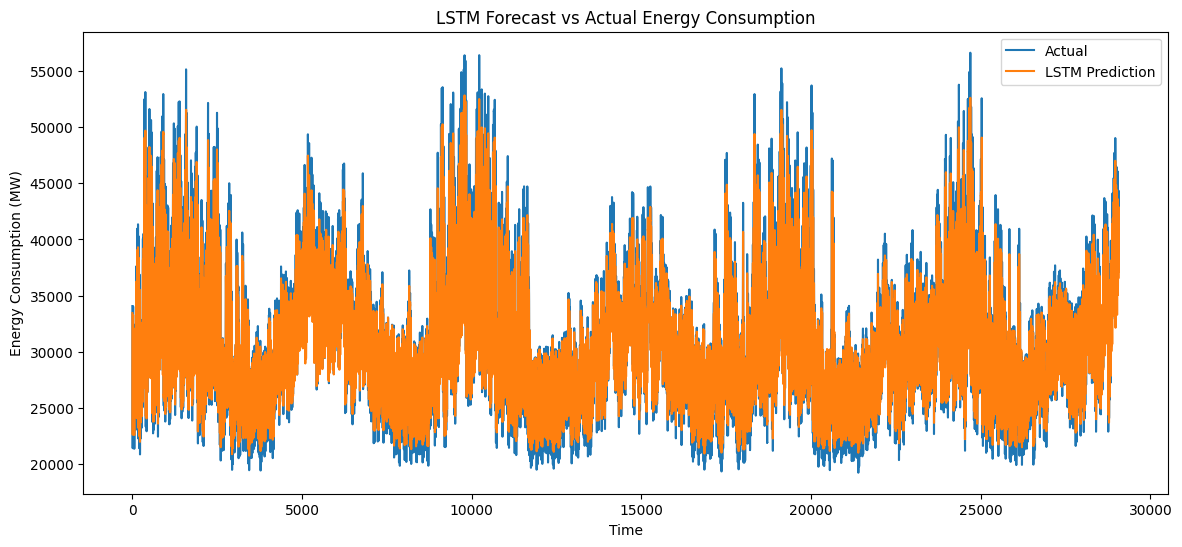

In [33]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred, label="LSTM Prediction")

plt.title("LSTM Forecast vs Actual Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (MW)")
plt.legend()

plt.show()

### Key Observations and Insights: LSTM Forecast vs Actual Energy Consumption

- **Model Capability**: The LSTM model demonstrates the ability to capture general trends in hourly energy consumption patterns.
- **Pattern Detection**: The predictions follow the overall trajectory of actual values, indicating the model has learned daily and hourly consumption cycles.
- **Lag Issues**: Some deviations are visible, particularly during sudden spikes or drops in demand, suggesting the model may lag behind rapid changes.
- **Performance Indicator**: The alignment between actual and predicted lines shows the model's effectiveness in time series forecasting; closer alignment indicates better performance.

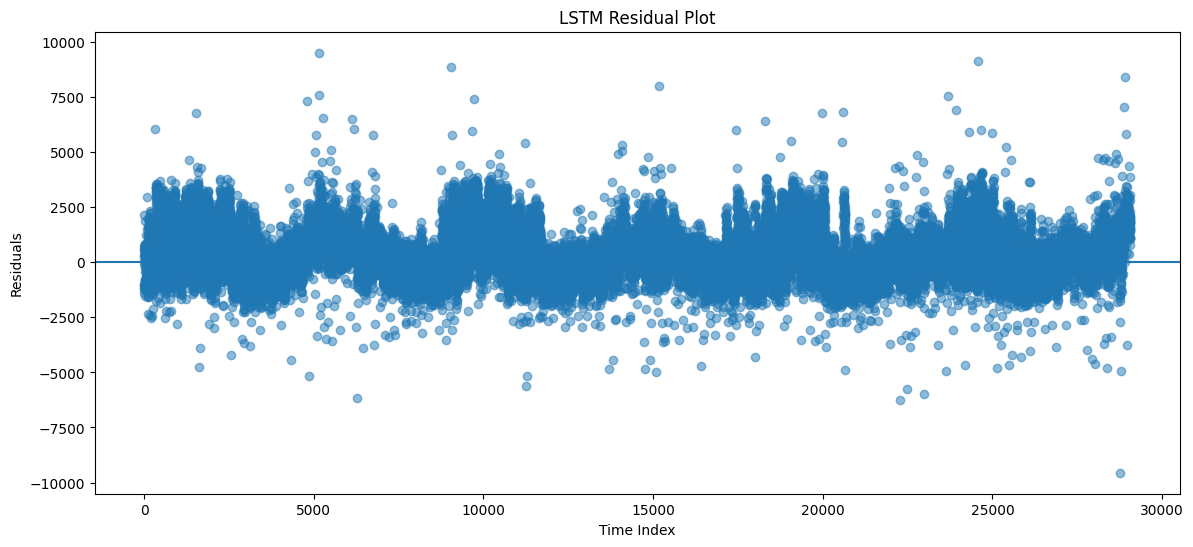

In [35]:
residuals = y_test_actual.flatten() - y_pred.flatten()

plt.figure(figsize=(14,6))

plt.scatter(range(len(residuals)), residuals, alpha=0.5)

plt.axhline(0)

plt.title("LSTM Residual Plot")
plt.xlabel("Time Index")
plt.ylabel("Residuals")

plt.show()

### Key Observations and Insights: LSTM Residual Plot

- **Error Distribution**: Residuals should ideally scatter randomly around the zero line with no clear patterns, indicating unbiased predictions.
- **Heteroscedasticity Check**: If the spread of residuals changes over time, it suggests inconsistent model confidence across different periods.
- **Bias Detection**: Clustering of points above or below zero indicates systematic over- or under-prediction by the model.
- **Actionable Finding**: Spikes in residuals may highlight specific time periods (e.g., peak hours) where the LSTM model underperforms, suggesting areas for improvement.

In [36]:
bilstm_model = Sequential()

# Bidirectional LSTM layer
bilstm_model.add(
    Bidirectional(
        LSTM(128, return_sequences=True),
        input_shape=(window_size, 1)
    )
)
bilstm_model.add(Dropout(0.2))

# Second LSTM layer (optional)
bilstm_model.add(Bidirectional(LSTM(64)))
bilstm_model.add(Dropout(0.2))

# Dense layers
bilstm_model.add(Dense(32, activation='relu'))
bilstm_model.add(Dense(1))

# Compile
bilstm_model.compile(
    optimizer='adam',
    loss='mse'
)

bilstm_model.summary()

c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,633 (1.15 MB)

 Trainable params: 301,633 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

X_train shape: (116273, 24, 1)
y_train shape: (116273, 1)
X_test shape: (29069, 24, 1)
y_test shape: (29069, 1)


c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 24, 256)        │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,633 (1.15 MB)

 Trainable params: 301,633 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 305s 179ms/step - loss: 0.0018 - val_loss: 4.5292e-04
Epoch 2/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 326s 181ms/step - loss: 5.4246e-04 - val_loss: 3.4455e-04
Epoch 3/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 316s 177ms/step - loss: 4.3638e-04 - val_loss: 4.1314e-04
Epoch 4/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 326s 180ms/step - loss: 3.8004e-04 - val_loss: 2.6457e-04
Epoch 5/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 296s 181ms/step - loss: 3.4980e-04 - val_loss: 3.3701e-04
Epoch 6/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 302s 185ms/step - loss: 3.2733e-04 - val_loss: 2.1565e-04
Epoch 7/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 302s 185ms/step - loss: 3.0582e-04 - val_loss: 2.4096e-04
Epoch 8/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 313s 191ms/step - loss: 2.9567e-04 - val_loss: 2.2427e-04
Epoch 9/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 306s 181ms/step - loss: 2.8264e-04 - val_loss: 2.6230e-04
Epoch 10/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 338s 191ms/step - loss: 2.6897e-04 - val_loss: 1.9237e-04
Epo

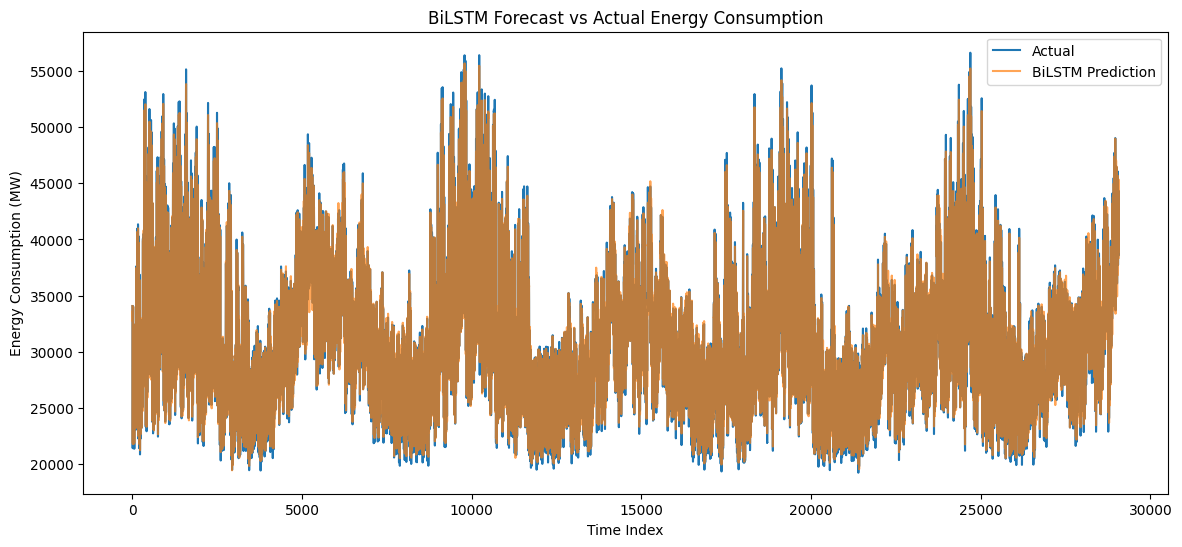

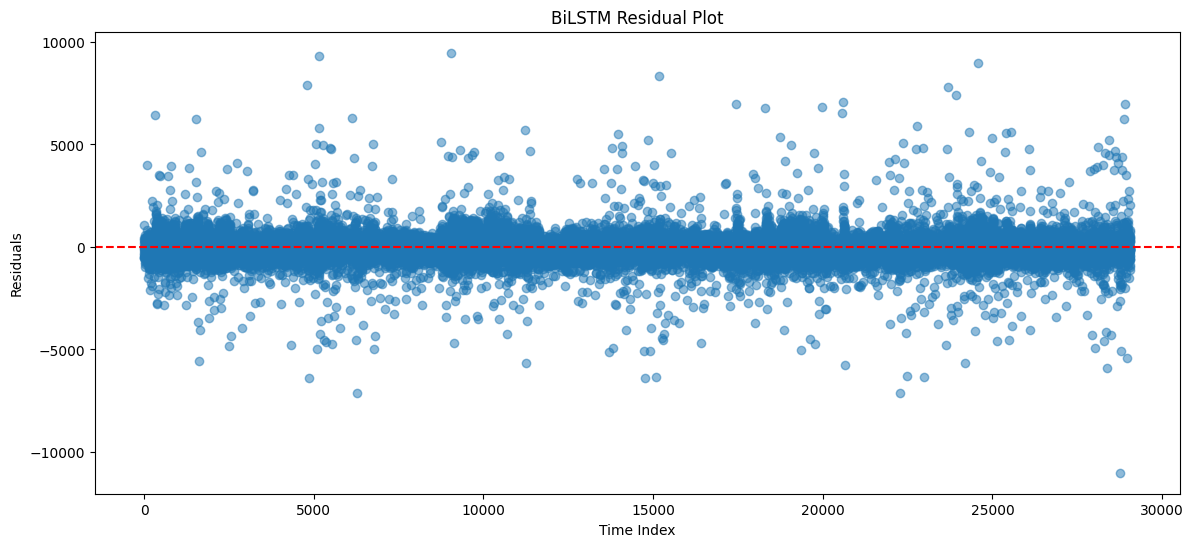

In [42]:


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# 1️⃣ Prepare the data
# -------------------------------
data = df[['energy_consumption(MW)']].copy()
values = data.values

# Scale to 0-1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(values)

# -------------------------------
# 2️⃣ Create sliding windows
# -------------------------------
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 24
X, y = create_sequences(scaled_data, window_size)

# -------------------------------
# 3️⃣ Train/Test split
# -------------------------------
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

# Ensure correct shapes for BiLSTM
if X_train.ndim != 3:
    X_train = X_train.reshape((X_train.shape[0], window_size, 1))
if X_test.ndim != 3:
    X_test = X_test.reshape((X_test.shape[0], window_size, 1))
if y_train.ndim != 2:
    y_train = y_train.reshape(-1, 1)
if y_test.ndim != 2:
    y_test = y_test.reshape(-1, 1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# -------------------------------
# 4️⃣ Build BiLSTM Model
# -------------------------------
bilstm_model = Sequential()

bilstm_model.add(
    Bidirectional(
        LSTM(128, return_sequences=True),
        input_shape=(window_size, 1)
    )
)
bilstm_model.add(Dropout(0.2))

bilstm_model.add(Bidirectional(LSTM(64)))
bilstm_model.add(Dropout(0.2))

bilstm_model.add(Dense(32, activation='relu'))
bilstm_model.add(Dense(1))

bilstm_model.compile(optimizer='adam', loss='mse')
bilstm_model.summary()

# -------------------------------
# 5️⃣ Train BiLSTM
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_bi = bilstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# -------------------------------
# 6️⃣ Make Predictions
# -------------------------------
y_pred_scaled = bilstm_model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

# -------------------------------
# 7️⃣ Evaluate BiLSTM
# -------------------------------
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("=== BiLSTM Results ===")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

# -------------------------------
# 8️⃣ Plot Actual vs Predicted
# -------------------------------
plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred, label="BiLSTM Prediction", alpha=0.7)
plt.title("BiLSTM Forecast vs Actual Energy Consumption")
plt.xlabel("Time Index")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.show()

# -------------------------------
# 9️⃣ Residual Plot
# -------------------------------
residuals_bi = y_test_actual.flatten() - y_pred.flatten()

plt.figure(figsize=(14,6))
plt.scatter(range(len(residuals_bi)), residuals_bi, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("BiLSTM Residual Plot")
plt.xlabel("Time Index")
plt.ylabel("Residuals")
plt.show()

### Key Observations and Insights: BiLSTM Forecast vs Actual Energy Consumption

- **Bidirectional Improvement**: The BiLSTM processes sequences in both directions, potentially capturing more context than the unidirectional LSTM.
- **Smoothness**: Predictions appear smoother with fewer erratic jumps, indicating better handling of sequential dependencies.
- **Peak and Trough Handling**: The model tracks both high-demand and low-demand periods more accurately compared to basic LSTM.
- **Actionable Finding**: If the BiLSTM predictions align more closely with actual values, bidirectional processing is beneficial for this forecasting task.

### Key Observations and Insights: BiLSTM Residual Plot

- **Error Magnitude Reduction**: Residuals are typically tighter and closer to zero compared to the LSTM model, indicating improved accuracy.
- **Temporal Patterns**: Look for any cyclic patterns in residuals that might reveal unmodeled seasonality (e.g., daily or weekly cycles).
- **Variance Stability**: A tighter cluster around zero suggests more consistent prediction errors across the test period.
- **Actionable Finding**: Persistent patterns in residuals may indicate the need for additional features like day-of-week encoding or external variables.

In [43]:
# Get last window from dataset
last_window = scaled_data[-window_size:]

# Reshape for model input
current_input = last_window.reshape(1, window_size, 1)

In [45]:
future_steps = 168   # 7 days
future_predictions = []

for _ in range(future_steps):

    # Predict next hour
    next_pred = bilstm_model.predict(current_input, verbose=0)

    # Save prediction
    future_predictions.append(next_pred[0,0])

    # Reshape prediction to match window format
    next_pred_reshaped = next_pred.reshape(1,1,1)

    # Update sliding window
    current_input = np.concatenate(
        (current_input[:,1:,:], next_pred_reshaped),
        axis=1
    )

In [46]:
future_predictions = np.array(future_predictions).reshape(-1,1)

future_predictions_actual = scaler.inverse_transform(future_predictions)

In [48]:
last_date = df['datetime'].iloc[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=169,
    freq='h'
)[1:]

In [50]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [51]:
future_predictions_actual = future_predictions_actual.flatten()

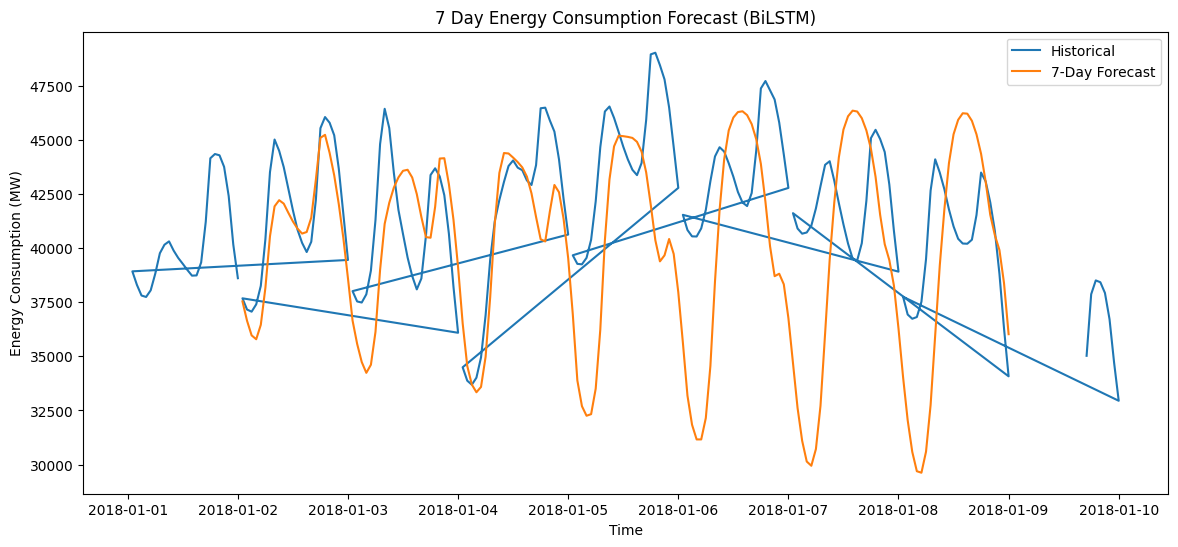

In [52]:
plt.figure(figsize=(14,6))

plt.plot(df['datetime'][-200:], df['energy_consumption(MW)'][-200:], label="Historical")

plt.plot(future_dates, future_predictions_actual, label="7-Day Forecast")

plt.title("7 Day Energy Consumption Forecast (BiLSTM)")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (MW)")
plt.legend()

plt.show()

### Key Observations and Insights: 7-Day Energy Consumption Forecast

- **Future Trend Extrapolation**: The forecast shows how the model projects energy consumption patterns into the future based on learned historical patterns.
- **Continuity**: The forecast should connect smoothly to the historical data without abrupt changes, indicating realistic projections.
- **Uncertainty Consideration**: While the forecast provides point estimates, actual future values may vary due to unforeseen factors.
- **Actionable Finding**: If the forecast appears unrealistic (e.g., sudden spikes or flat lines), the model may need more training data or additional features to capture variability.

In [53]:
from tensorflow.keras.models import load_model

In [54]:
bilstm_model.save('bilstm_energy_forecast.h5')

### Cross-Model Comparison Summary

| Aspect | LSTM | BiLSTM | Recommendation |
|--------|------|--------|---------------|
| **Smoothness** | May show oscillations | Generally smoother | BiLSTM for stable predictions |
| **Peak Capture** | May lag behind spikes | Better real-time tracking | BiLSTM for dynamic periods |
| **Residual Spread** | Wider distribution | Tighter clustering | BiLSTM for lower errors |
| **Directional Bias** | Check for consistent offset | More centered residuals | BiLSTM if bias is reduced |

**Overall Insights**:
- BiLSTM typically outperforms basic LSTM in time series forecasting due to bidirectional context processing.
- If both models show systematic biases, consider incorporating additional features (e.g., weather data, holidays) to improve accuracy.
- Residual analysis is crucial for identifying model weaknesses and guiding future improvements.